In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.layers import Input, InputLayer, Dense, LSTM, Embedding, Bidirectional

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

from keras.callbacks import EarlyStopping

from nltk.corpus import stopwords

In [2]:
def generar_diccionario(textos, sw, N):
    cv = CountVectorizer(stop_words = sw, max_features = N)
    cv.fit_transform(textos)
    diccionario = cv.vocabulary_
    diccionario = dict([(palabra, i+2) for i, palabra in enumerate(diccionario)])
    diccionario['DESC'] = 0
    diccionario['PAD'] = 1 
    return diccionario

In [3]:
def procesar_cadena(texto, diccionario, stop_words, T):
    # Identificar palabras en el texto
    palabras = re.findall(r'\b\w+\b', texto.lower())
    palabras = list(filter(lambda x: x not in stop_words, palabras))
    resultado = [] 
    for i in range(0, T):
        if i < len(palabras): 
            if palabras[i] in diccionario:
                resultado.append(diccionario[palabras[i]])
            else:
                resultado.append(diccionario['DESC'])
        else:
            resultado.append(diccionario['PAD'])
    return np.array(resultado)

In [4]:
# Parámetros configurables
N = 20000  # Número de palabras del diccionario
T = 100    # Longitud prefijada de la reseña
EPOCHS = 10
NEURONAS_CAPA = 128

In [5]:
stop_words=['a', 'about', 'an', 'and', 'as', 'at', 'be', 'because', 'been', 
    'being', 'by', 'during', 'each', 'for', 'from', 'he', 'he\'d', 'he\'ll',
    'he\'s', 'her', 'him', 'his', 'how', 'i', 'i\'d', 'i\'ll', 'i\'m', 'i\'ve',
    'if', 'in', 'into', 'it', 'it\'s', 'its', 'let\'s', 'of', 'or', 'our', 
    'out', 'over', 'same', 'she', 'she\'d', 'she\'ll', 'she\'s', 'so', 'some'
    'such', 'than', 'that', 'that\'s', 'the', 'them', 'then', 'there', 'these',
    'they', 'they\'d', 'they\'ll', 'they\'re', 'they\'ve', 'this', 'those',
    'through', 'to', 'until', 'very', 'we', 'we\'d', 'we\'ll', 'we\'re', 
    'we\'ve', 'what', 'what\'s', 'when', 'when\'s', 'where', 'where\'s', 'which',
    'while', 'who', 'who\'s', 'whom', 'why', 'why\'s', 'with', 'would', 
    'wouldn\'t', 'you', 'you\'d', 'you\'ll', 'you\'re', 'you\'ve', 'your', 
    'yours']

In [6]:
path = "/kaggle/input/tuits-desastres-dataset/tuits_desastres.csv"
datos = pd.read_csv(path)

In [7]:
# Variable objetivo
y = datos.iloc[:, -1]
num_clases = len(y.unique())

# Codificamos con "one hot" las posibles categorías finales
#y = pd.get_dummies(datos['target'], columns=['target'])
y = datos['target']

In [8]:
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
7608    1
7609    1
7610    1
7611    1
7612    1
Name: target, Length: 7613, dtype: int64


In [9]:
# Textos de reseñas
textos = datos['text']

In [10]:
def mostrar_primeras_filas_textos(textos):
    for i in range(11):
        print(f"{i}: {textos[i]}")

mostrar_primeras_filas_textos(textos)

0: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
1: Forest fire near La Ronge Sask. Canada
2: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
3: 13,000 people receive #wildfires evacuation orders in California 
4: Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
5: #RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wildfires
6: #flood #disaster Heavy rain causes flash flooding of streets in Manitou, Colorado Springs areas
7: I'm on top of the hill and I can see a fire in the woods...
8: There's an emergency evacuation happening now in the building across the street
9: I'm afraid that the tornado is coming to our area...
10: Three people died from the heat wave so far


In [11]:
def limpiar_tweet(tweet):
    tweet = re.sub(r'@\w+', '', tweet)  # Elimina menciones
    tweet = re.sub(r'#\w+', '', tweet)  # Elimina hashtags
    tweet = re.sub(r'http\S+|www\S+', '', tweet)  # Elimina links
    tweet = re.sub(r'[^\w\s]', '', tweet)  # Caracteres especiales
    tweet = re.sub(r'\s+', ' ', tweet).strip()  # Espacios extra
    return tweet.lower()  # Convertir a minúsculas

tweets_limpiados = [limpiar_tweet(t) for t in textos]

In [12]:
mostrar_primeras_filas_textos(tweets_limpiados)

0: our deeds are the reason of this may allah forgive us all
1: forest fire near la ronge sask canada
2: all residents asked to shelter in place are being notified by officers no other evacuation or shelter in place orders are expected
3: 13000 people receive evacuation orders in california
4: just got sent this photo from ruby as smoke from pours into a school
5: update california hwy 20 closed in both directions due to lake county fire
6: heavy rain causes flash flooding of streets in manitou colorado springs areas
7: im on top of the hill and i can see a fire in the woods
8: theres an emergency evacuation happening now in the building across the street
9: im afraid that the tornado is coming to our area
10: three people died from the heat wave so far


In [13]:
# Utilizando librería en lugar de la lista creada anteriormente
stop_words = list(stopwords.words('english'))

X = []
diccionario = generar_diccionario(textos, stop_words, N)
for texto in textos:
    X.append(procesar_cadena(texto, diccionario, stop_words, T))
    
# X contendrá las reseñas codificadas y rellenas con la misma longitud
X = np.array(X)

In [14]:
print(X)

[[    2     3     4 ...     1     1     1]
 [    9    10    11 ...     1     1     1]
 [   16    17    18 ...     1     1     1]
 ...
 [10344 10345  9439 ...     1     1     1]
 [  185  4411     0 ...     1     1     1]
 [ 1451  4798 16142 ...     1     1     1]]


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modelo

In [16]:
N = 50 # Tamaño del vocabulario
D = 50 # Dimensión del embedding

In [17]:
embedding_layer = Embedding(input_dim=N, output_dim=D)
entrada = X
embeddings = embedding_layer(entrada)

#print('Representación de {}'.format(str(entrada)))
#print(embeddings.numpy())

In [18]:
model = tf.keras.Sequential([
  Embedding(input_dim=N, output_dim=D),
  Bidirectional(LSTM(128, activation='tanh')),
  #Bidirectional(LSTM(64)),
  #Bidirectional(LSTM(32)),   
  Dense(50, activation='relu'),
  Dense(1, activation='sigmoid')])

model.summary()

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

In [20]:
epochs = 20

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5825 - loss: 0.6750 - val_accuracy: 0.5952 - val_loss: 0.6497
Epoch 2/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6220 - loss: 0.6376 - val_accuracy: 0.6232 - val_loss: 0.6367
Epoch 3/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6228 - loss: 0.6298 - val_accuracy: 0.6026 - val_loss: 0.6379
Epoch 4/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6101 - loss: 0.6313 - val_accuracy: 0.6010 - val_loss: 0.6413
Epoch 5/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6179 - loss: 0.6367 - val_accuracy: 0.6051 - val_loss: 0.6473
Epoch 6/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6379 - loss: 0.6232 - val_accuracy: 0.6141 - val_loss: 0.6357
Epoch 7/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6263 - loss: 0.6346 - val_accuracy: 0.6199 - val_loss: 0.6364
Epoch 8/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6177 - loss: 0.6310 - val_accu

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6233 - loss: 0.6259
Pérdida: 0.6216273307800293, Precisión: 0.6388706564903259


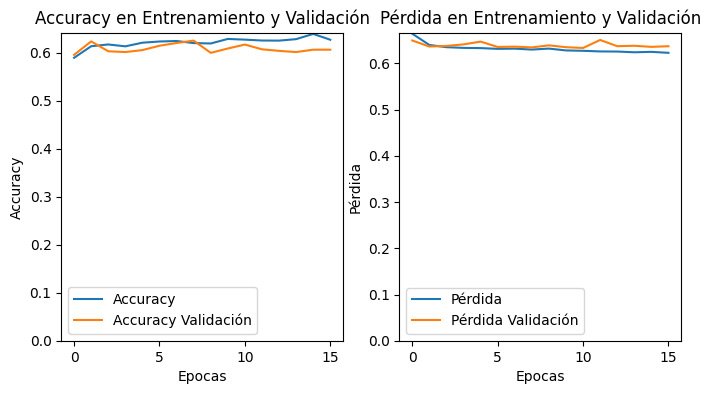

In [21]:
def graficas_metricas_entrenamiento(history):
    # Graficando la accuracy y loss a lo largo del entrenamiento
    
    # Información history
    history_dict = history.history
    
    # Separando accuracy en training y validación
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    
    # Separando loss en training y validación
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    
    # Información adicional
    lossTest, accTest = model.evaluate(X_test, y_test)
    #lossTest, accTest = model2.evaluate(X_test, y_test)
    print(f"Pérdida: {lossTest}, Precisión: {accTest}")
    
    # Dibujar las gráficas
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc)
    plt.plot(val_acc)
    plt.title('Accuracy en Entrenamiento y Validación')
    plt.xlabel('Epocas')
    plt.ylabel('Accuracy')
    plt.legend(['Accuracy', 'Accuracy Validación'])
    plt.ylim(bottom=0)
    
    plt.subplot(1, 2, 2)
    plt.plot(loss)
    plt.plot(val_loss)
    plt.title('Pérdida en Entrenamiento y Validación')
    plt.xlabel('Epocas')
    plt.ylabel('Pérdida')
    plt.legend(['Pérdida', 'Pérdida Validación'])
    plt.ylim(bottom=0)
    
    plt.show()

graficas_metricas_entrenamiento(history)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Classification Report:
              precision    recall  f1-score   support

 No desastre       0.67      0.74      0.70       874
    Desastre       0.59      0.50      0.54       649

    accuracy                           0.64      1523
   macro avg       0.63      0.62      0.62      1523
weighted avg       0.63      0.64      0.63      1523



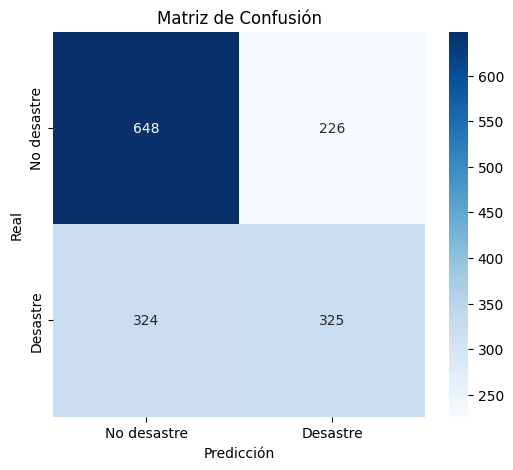

In [22]:
def reporte_matriz_conf(model):
    y_pred = model.predict(X_test)
    y_pred = np.round(y_pred).astype(int)

    conf_matrix = confusion_matrix(y_test, y_pred)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["No desastre", "Desastre"]))

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No desastre", "Desastre"],
        yticklabels=["No desastre", "Desastre"],
    )
    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # Métricas adicionales
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)


reporte_matriz_conf(model)